# Predicting UFC fights and Observing Fight Data Trends
## Izak Boardman | Project 2 | DSCI 311

In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns
sns.set_palette("colorblind")
pd.set_option('display.max_columns', None)  # Display all rows

#### Data Explanation

* R_fighter, B_fighter: Fighter names
* R_odds, B_odds: The American odds that the fighter will win. Usually scraped from bestfightodds.com
* R_ev, B_ev: The profit on a 100 credit winning bet
* date: The date of the fight
* location: The location of the fight
* country: The country the fight occurs in
* Winner: The winner of the fight [Red, Blue, or Draw]
* title_bout: Was this a title bout?
* weight_class: The weight class of the bout
* gender: Gender of the combatants
* no_of_rounds: The number of rounds in the fight
* B_current_lose_streak, R_current_lose_streak: Current losing streak
* B_current_win_streak, R_current_win_streak: Current winning streak
* B_draw, R_draw: Number of draws
* B_avg_SIG_STR_landed, R_avg_SIG_STR_landed : Significant Strikes Landed per minute
* B_avg_SIG_STR_pct, R_avg_SIG_STR_pct: Significant Striking Accuracy
* B_avg_SUB_ATT, R_avg_SUB_ATT: Average Submissions Attempted per 15 Minutes
* B_avg_TD_landed, R_avg_TD_landed: Average takedowns landed per 15 minutes
* B_avg_TD_pct, R_avg_TD_pct: Takedown accuracy
* B_longest_win_streak, R_longest_win_streak: Longest winning streak
* B_losses, R_losses: Total number of losses
* B_total_rounds_fought, R_total_rounds_fought: Total rounds fought
* B_total_title_bouts, R_total_title_bouts: Total number of title bouts
* B_win_by_Decision_Majority, R_win_by_Decision_Majority: Wins by Majority Decision
* B_win_by_Decision_Split, R_win_by_Decision_Split: Wins by Split Decision
* B_win_by_Decision_Unanimous, R_win_by_Decision_Unanimous: Wins by Unanimous Decision
* B_win_by_KO/TKO, R_win_by_KO/TKO: Wins by KO/TKO
* B_win_by_Submission, R_win_by_Submission: Wins by Submission
* B_win_by_TKO_Doctor_Stoppage, R_win_by_TKO_Doctor_Stoppage: Wins by Doctor Stoppage
* B_wins, R_wins: Total career wins
* B_Stance, R_stance: Fighter stance
* B_Height_cms, R_Height_cms: Fighter height in cms
* B_Reach_cms, R_Reach_cms: Fighter reach in cms
* B_Weight_lbs, R_Weight_lbs: Fighter weight in pounds
* B_age, R_age: Fighter age
* lose_streak_dif: (Blue lose streak) - (Red lose streak) winstreakdif: (Blue win streak) - (Red win streak)
* longest_win_streak_dif: (Blue longest win streak) - (Red longest win streak)
* win_dif: (Blue wins) - (Red wins)
* loss_dif: (Blue losses) - (Red losses)
* total_round_dif: (Blue total rounds fought) - (Red total rounds fought)
* total_title_bout_dif: (Blue number of title fights) - (Red number of title fights)
* ko_dif: (Blue wins by KO/TKO) - (Red wins by KO/TKO)
* sub_dif: (Blue wins by submission) - (Red wins by submission)
* height_dif: (Blue height) - (Red height) in cms
* reach_dif: (Blue reach) - (Red reach) in cms
* age_dif: (Blue age) - (Red age)
* sig_str_dif: (Blue sig strikes per minute) - (Red sig strikes per minute)
* avg_sub_att_dif: (Blue submission attempts) - (Red submission attempts)
* avg_td_dif: (Blue TD attempts) - (Red TD attempts)
* empty_arena: Did this fight occur in an empty arena? (1,0)
* constant_1: The number 1
* B_match_weightclass_rank, R_match_weightclass_rank: Rank in the weightclass this bout takes place in
* R_Women's Flyweight_rank, B_Women's Flyweight_rank: Rank in the Women's Flyweight Division
* B_Women's Featherweight_rank, 'RWomen's Featherweightrank: Rank in the Women's Featherweight Division BWomen's Strawweightrank, 'R_Women's Strawweight_rank: Rank in the Women's Strawweight Division
* B_Women's Bantamweight_rank, R_Women's Bantamweight_rank: Rank in the Women's Bantamweight Division
* B_Heavyweight_rank, R_Heavyweight_rank: Heavyweight rank
* B_Light Heavyweight_rank, R_Light Heavyweight rank: Light Heavyweight rank
* B_Middleweight_rank, R_Middleweight_rank: Middleweight rank
* B_Welterweight_rank, R_Welterweight_rank: Welterweight rank
* B_Lightweight_rank, R_Lightweight_rank: Lightweight rank
* B_Featherweight_rank, R_Featherweight_rank: Featherweight rank
* B_Bantamweight_rank, R_Bantamweight_rank: Bantamweight rank
* B_Flyweight_rank, R_Flyweight_rank: Flyweight rank
* B_Pound-for-Pound_rank, R_Pound-for-Pound_rank: Pound-for-Pound rank
* better_rank: Who has the better rank (Red, Blue, neither)
* finish: How the fight finished
* finish_details: More details about the finish if available.
* finish_round: The round the fight ended
* finish_round_time: Time in the round of the finish
* total_fight_time_secs: Total time of the fight in seconds

## Reading in data from Kaggle https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset/data

In [2]:
data = pd.read_csv('archive/ufc-master.csv')

data.head()

,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,TitleBout,WeightClass,Gender,NumberOfRounds,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,BlueWeightLbs,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedWeightLbs,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,EmptyArena,BMatchWCRank,RMatchWCRank,RWFlyweightRank,RWFeatherweightRank,RWStrawweightRank,RWBantamweightRank,RHeavyweightRank,RLightHeavyweightRank,RMiddleweightRank,RWelterweightRank,RLightweightRank,RFeatherweightRank,RBantamweightRank,RFlyweightRank,RPFPRank,BWFlyweightRank,BWFeatherweightRank,BWStrawweightRank,BWBantamweightRank,BHeavyweightRank,BLightHeavyweightRank,BMiddleweightRank,BWelterweightRank,BLightweightRank,BFeatherweightRank,BBantamweightRank,BFlyweightRank,BPFPRank,BetterRank,Finish,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Neil Magny,Carlos Prates,550.0,-800.0,550.0000,12.5000,2024-11-09,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,5,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,170,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,170,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,KO/TKO,Punch,1.0,4:50,290.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,Gerald Meerschaert,Reinier de Ridder,250.0,-310.0,250.0000,32.2581,2024-11-09,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,185,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,185,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,SUB,Arm Triangle,3.0,1:44,704.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,Gaston Bolanos,Cortavious Romious,205.0,-250.0,205.0000,40.0000,2024-11-09,"Las Vegas, Nevada, USA",USA,Red,False,Bantamweight,MALE,3,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,135,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,135,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,NaN,3.0,5:00,900.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,Luana Pinheiro,Gillian Robertson,360.0,-470.0,360.0000,21.2766,2024-11-09,"Las Vegas, Nevada, USA",USA,Blue,False,Women's Strawweight,FEMALE,3,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,115,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,115,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,NaN,14.0,13.0,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,NaN,3.0,5:00,900.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,Mansur Abdul-Malik,Dusko Todorovic,-485.0,370.0,20.6186,370.0000,20

# EDA and Inference
## Main Question:

### What features in the Ultimate UFC Datasets have the strongest correlation to fighters winning, and how well can we predict the outcome of these matches (Red wins or Blue wins)

#### Dropping cols with shared varibles between fighters

In [3]:
cols_to_drop_repeat = ['RedFighter', 'BlueFighter', 'Date', 'Location', 'Country', 'WeightClass', 'Gender', 'FinishDetails', 'EmptyArena', 'BlueWeightLbs', 'RedWeightLbs', 'FinishRoundTime', 'TotalFightTimeSecs']
data = data.drop(columns = cols_to_drop_repeat)
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,NumberOfRounds,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BMatchWCRank,RMatchWCRank,RWFlyweightRank,RWFeatherweightRank,RWStrawweightRank,RWBantamweightRank,RHeavyweightRank,RLightHeavyweightRank,RMiddleweightRank,RWelterweightRank,RLightweightRank,RFeatherweightRank,RBantamweightRank,RFlyweightRank,RPFPRank,BWFlyweightRank,BWFeatherweightRank,BWStrawweightRank,BWBantamweightRank,BHeavyweightRank,BLightHeavyweightRank,BMiddleweightRank,BWelterweightRank,BLightweightRank,BFeatherweightRank,BBantamweightRank,BFlyweightRank,BPFPRank,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,Blue,False,5,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,KO/TKO,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,Blue,False,3,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,SUB,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,Red,False,3,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,Blue,False,3,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,14.0,13.0,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,Red,False,3,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,Orthodox,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,Orthodox,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,KO/TKO,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


#### Observing Null values and dropping columns accordingly

In [4]:
null_vals = data.isnull().sum().sort_values(ascending=False)
null_vals.index

for idx in null_vals.index: 
    if null_vals[idx] != 0: 
        print(f"col_name: {idx}, null vals: {null_vals[idx]}\n")

cols_to_drop_na = [
    'BMatchWCRank', 'RMatchWCRank', 'RWFlyweightRank', 'RWFeatherweightRank', 
    'RWStrawweightRank', 'RWBantamweightRank', 'RHeavyweightRank', 'RLightHeavyweightRank', 
    'RMiddleweightRank', 'RWelterweightRank', 'RLightweightRank', 'RFeatherweightRank', 
    'RBantamweightRank', 'RFlyweightRank', 'RPFPRank', 'BWFlyweightRank', 'BWFeatherweightRank', 
    'BWStrawweightRank', 'BWBantamweightRank', 'BHeavyweightRank', 'BLightHeavyweightRank', 
    'BMiddleweightRank', 'BWelterweightRank', 'BLightweightRank', 'BFeatherweightRank', 
    'BBantamweightRank', 'BFlyweightRank', 'BPFPRank', 'NumberOfRounds'
]
data = data.drop(columns = cols_to_drop_na)
data.head()

col_name: BWFeatherweightRank, null vals: 6488

col_name: RWFeatherweightRank, null vals: 6480

col_name: BPFPRank, null vals: 6422

col_name: BWFlyweightRank, null vals: 6417

col_name: RWFlyweightRank, null vals: 6393

col_name: BWStrawweightRank, null vals: 6390

col_name: BWBantamweightRank, null vals: 6382

col_name: BBantamweightRank, null vals: 6371

col_name: BLightHeavyweightRank, null vals: 6371

col_name: BWelterweightRank, null vals: 6371

col_name: BLightweightRank, null vals: 6370

col_name: BFeatherweightRank, null vals: 6366

col_name: BFlyweightRank, null vals: 6359

col_name: BMiddleweightRank, null vals: 6352

col_name: RWStrawweightRank, null vals: 6344

col_name: BHeavyweightRank, null vals: 6343

col_name: RWBantamweightRank, null vals: 6335

col_name: RFeatherweightRank, null vals: 6314

col_name: RBantamweightRank, null vals: 6310

col_name: RMiddleweightRank, null vals: 6307

col_name: RLightHeavyweightRank, null vals: 6307

col_name: RLightweightRank, null val

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,Blue,False,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,Red,KO/TKO,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,Blue,False,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,neither,SUB,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,Red,False,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,neither,U-DEC,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,Blue,False,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,Red,U-DEC,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,Red,False,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,Orthodox,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,Orthodox,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,neither,KO/TKO,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


#### After null cols are taken care of we can move on to encoding features. Catigorical features need to be encoded and preserved for further analysis. 

#### Encoding Catigorical Features

In [5]:
data['TitleBout'] = data['TitleBout'].apply(lambda x: 0 if x == False else 1) #0 false 1 True
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,Blue,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,Red,KO/TKO,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,Blue,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,neither,SUB,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,Red,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,neither,U-DEC,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,Blue,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,Red,U-DEC,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,Red,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,Orthodox,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,Orthodox,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,neither,KO/TKO,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


In [6]:
data['Winner'] = data['Winner'].apply(lambda x: 0 if x == 'Blue' else 1) #blue win 0, red win 1
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,Red,KO/TKO,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,neither,SUB,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,neither,U-DEC,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,Red,U-DEC,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,Orthodox,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,Orthodox,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,neither,KO/TKO,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


In [7]:

data = data[~data['Finish'].isin(['DQ', 'Overturned'])]
data['Finish'] = data['Finish'].apply(lambda x: 0 if x == "KO/TKO" 
                                              else (1 if x == "SUB" 
                                                    else (2 if x in ["S-DEC", "M-DEC", "U-DEC"] else x)))
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,Switch,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,Orthodox,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,Red,0.0,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,Southpaw,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,Southpaw,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,neither,1.0,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,Southpaw,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,Orthodox,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,neither,2.0,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,Orthodox,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,Orthodox,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,Red,2.0,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,Orthodox,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,Orthodox,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,neither,0.0,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


In [8]:
data['BlueStance'].value_counts()

BlueStance
Orthodox       4797
Southpaw       1265
Switch          402
Switch            1
Open Stance       1
Name: count, dtype: int64

In [9]:
data['BlueStance'] = data['BlueStance'].apply(lambda x: 0 if x == 'Orthodox'
                                                    else (1 if x == 'Southpaw'
                                                        else (2 if x in ["Switch", 'Switch ', "Open Stance"] else x)))

data['RedStance'] = data['BlueStance'].apply(lambda x: 0 if x == 'Orthodox'
                                                    else (1 if x == 'Southpaw'
                                                        else (2 if x in ["Switch", 'Switch ', "Open Stance"] else x)))
data.head()


,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,2.0,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,2.0,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,Red,0.0,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,1.0,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,1.0,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,neither,1.0,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,1.0,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,1.0,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,neither,2.0,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,0.0,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,0.0,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,Red,2.0,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,0.0,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,0.0,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,neither,0.0,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


In [10]:
data['BetterRank'] = data['BetterRank'].apply(lambda x: -1 if x == "Red" else (1 if x == "Blue" else 0))
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,2.0,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,2.0,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,-1,0.0,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,1.0,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,1.0,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,0,1.0,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,1.0,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,1.0,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,0,2.0,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,0.0,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,0.0,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,-1,2.0,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,0.0,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,0.0,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,0,0.0,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


Correlation of features with target:
Winner               1.000000
BlueOdds             0.351593
BlueExpectedValue    0.320603
BlueDecOdds          0.233921
BKOOdds              0.208209
                       ...   
RSubOdds            -0.157863
RedDecOdds          -0.171674
RKOOdds             -0.199582
RedExpectedValue    -0.324550
RedOdds             -0.344376
Name: Winner, Length: 76, dtype: float64


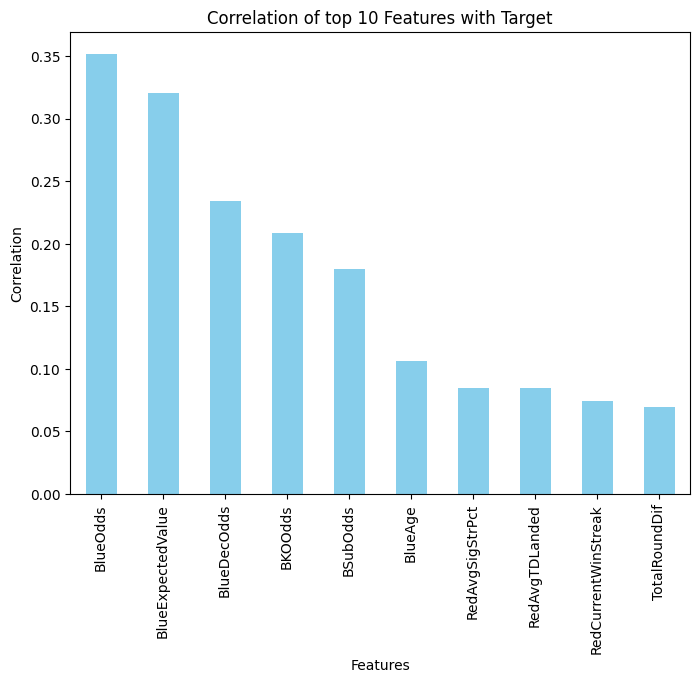

In [11]:

correlation_matrix = data.corr()
target_correlation = correlation_matrix['Winner'].sort_values(ascending=False)


print("Correlation of features with target:")
print(target_correlation)
target_correlation = target_correlation[:11]
plt.figure(figsize=(8, 6))
target_correlation[1:].plot(kind='bar', color='skyblue')
plt.title('Correlation of top 10 Features with Target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()

In [12]:
top_features = list(target_correlation.index)
top_features

['Winner',
 'BlueOdds',
 'BlueExpectedValue',
 'BlueDecOdds',
 'BKOOdds',
 'BSubOdds',
 'BlueAge',
 'RedAvgSigStrPct',
 'RedAvgTDLanded',
 'RedCurrentWinStreak',
 'TotalRoundDif']

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_ol

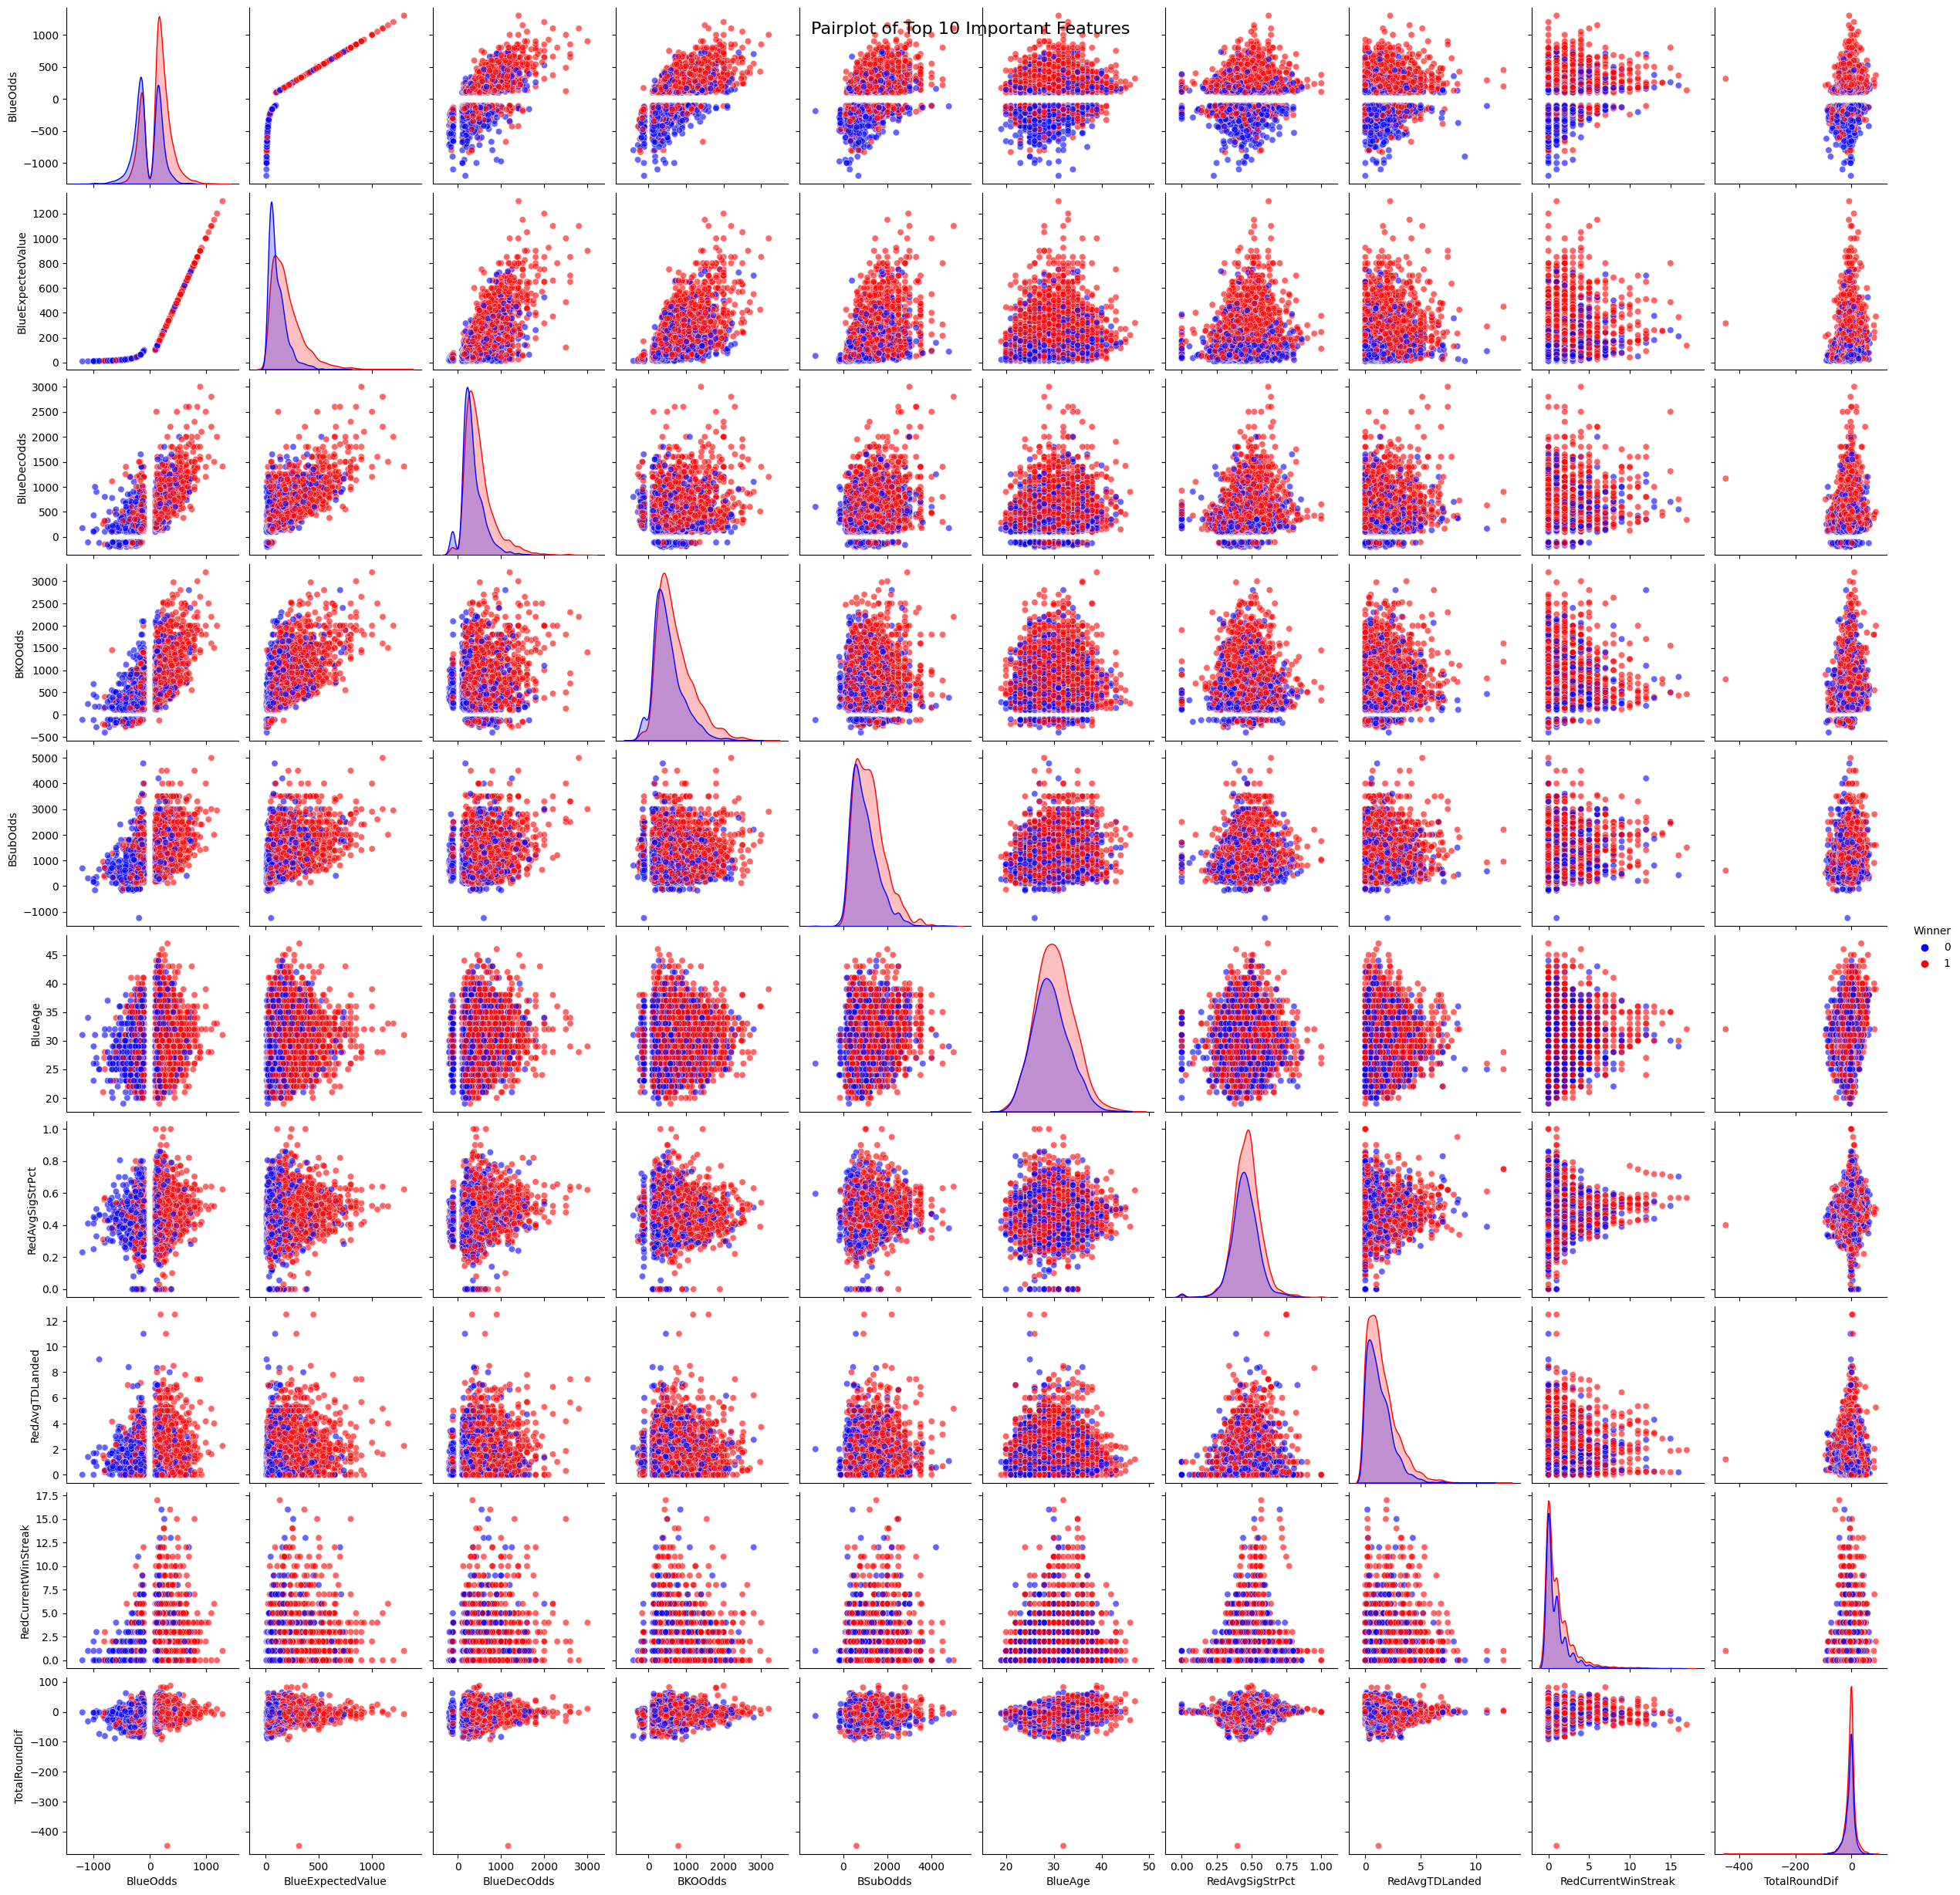

In [13]:
data_subset = data[target_correlation.index]

sns.pairplot(data_subset, hue='Winner', palette={0: 'blue', 1: 'red'}, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Top 10 Important Features", size=16)
plt.show()

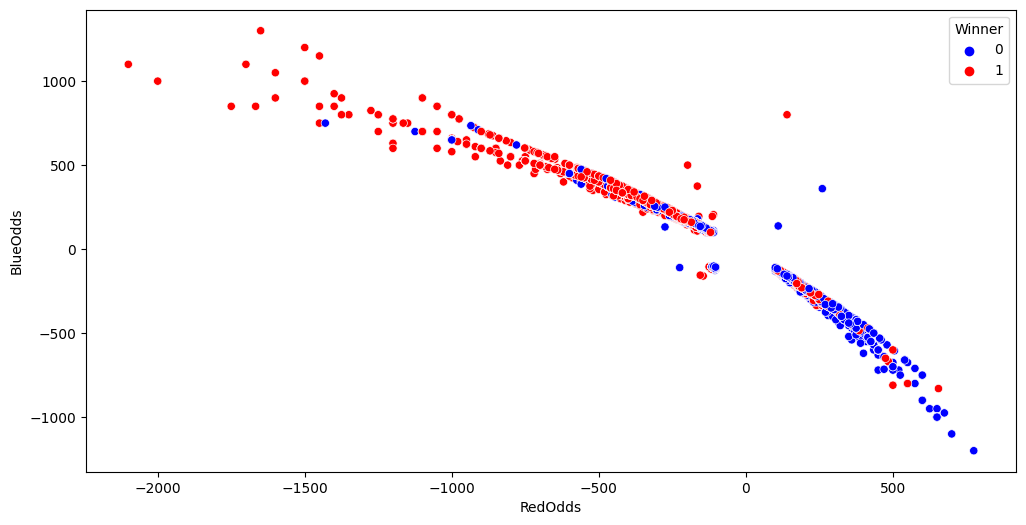

In [14]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='RedOdds', y='BlueOdds', hue='Winner', palette={1:"Red", 0:"Blue"})

plt.show()

#### Based on this pairplot it can be seen that red/blue odds and expected values are correlated to winning. This makes sense due to the fact that odds and ev's are derived from predictive modeling. Lets see if I can engineer seperate features to avoide predictive metrics. The above scatter plot shows the majority of red wins occur when red is favored (-odds) and blue wins occur when blue is favored (-odds)

#### Though I will be removing most odds based features it is interesting to observe the pattern at which red and blue win when they are favored or underdog (vegas knows what theyre doing). Blue and red win respectivly when they are favored, but the UFC is a sport of upsets so some interesting ones can be observed at high positive odds for red or blue (positive odds = underdog)

## Engineering Features and Removing Redundance

In [15]:
data.head()

,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,550.0,-800.0,550.0000,12.5000,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,2.0,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,2.0,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,-1,0.0,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0
1,250.0,-310.0,250.0000,32.2581,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,1.0,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,1.0,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,0,1.0,3.0,700.0,200.0,600.0,165.0,1400.0,450.0
2,205.0,-250.0,205.0000,40.0000,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,1.0,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,1.0,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,0,2.0,3.0,550.0,275.0,3000.0,165.0,380.0,450.0
3,360.0,-470.0,360.0000,21.2766,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,0.0,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,0.0,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,-1,2.0,3.0,600.0,250.0,2200.0,110.0,900.0,500.0
4,-485.0,370.0,20.6186,370.0000,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,0.0,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,0.0,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,0,0.0,1.0,600.0,NaN,800.0,NaN,-250.0,NaN


##### Because expected value represents the money won on a 100 unit bet it can sufice to replace +/- odds. I will calculate EvDiff as a metric to combine ev and odds. (Blue - Red in correspondance with pre engineered features)

In [16]:
data['EvDiff'] = data['BlueExpectedValue'] - data['RedExpectedValue']
data = data.drop(columns=['RedExpectedValue', 'BlueExpectedValue', 'RedOdds', 'BlueOdds'])
data.head()

,Winner,TitleBout,BlueCurrentLoseStreak,BlueCurrentWinStreak,BlueDraws,BlueAvgSigStrLanded,BlueAvgSigStrPct,BlueAvgSubAtt,BlueAvgTDLanded,BlueAvgTDPct,BlueLongestWinStreak,BlueLosses,BlueTotalRoundsFought,BlueTotalTitleBouts,BlueWinsByDecisionMajority,BlueWinsByDecisionSplit,BlueWinsByDecisionUnanimous,BlueWinsByKO,BlueWinsBySubmission,BlueWinsByTKODoctorStoppage,BlueWins,BlueStance,BlueHeightCms,BlueReachCms,RedCurrentLoseStreak,RedCurrentWinStreak,RedDraws,RedAvgSigStrLanded,RedAvgSigStrPct,RedAvgSubAtt,RedAvgTDLanded,RedAvgTDPct,RedLongestWinStreak,RedLosses,RedTotalRoundsFought,RedTotalTitleBouts,RedWinsByDecisionMajority,RedWinsByDecisionSplit,RedWinsByDecisionUnanimous,RedWinsByKO,RedWinsBySubmission,RedWinsByTKODoctorStoppage,RedWins,RedStance,RedHeightCms,RedReachCms,RedAge,BlueAge,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds,EvDiff
0,0,0,0,4,0,4.39,0.57,0.0,0.44,1.00,4,0,7,0,0,0,0,4,0,0,4,2.0,185.42,198.12,1,0,0,3.43,0.46,0.2,2.12,0.38,7,11,88,0,0,4,10,6,2,0,22,2.0,190.50,203.20,37,31,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,-1,0.0,1.0,1100.0,800.0,1600.0,800.0,2000.0,-400.0,-537.5000
1,0,0,0,0,0,3.24,0.57,1.3,6.39,0.38,0,0,0,0,0,0,0,0,0,0,0,1.0,193.04,198.12,0,2,0,3.10,0.45,1.5,2.01,0.35,3,9,43,0,0,0,0,1,11,0,12,1.0,185.42,195.58,36,34,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,0,1.0,3.0,700.0,200.0,600.0,165.0,1400.0,450.0,-217.7419
2,1,0,0,1,0,2.10,0.37,1.0,1.97,0.66,1,1,4,0,0,0,1,0,0,0,1,1.0,162.56,172.72,1,0,0,3.74,0.50,0.0,0.78,1.00,1,1,5,0,0,0,1,0,0,0,1,1.0,170.18,175.26,32,30,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,0,2.0,3.0,550.0,275.0,3000.0,165.0,380.0,450.0,-165.0000
3,0,0,0,2,0,2.89,0.48,1.0,2.68,0.39,2,6,37,0,0,0,2,2,7,0,11,0.0,165.10,160.02,2,0,0,3.42,0.40,0.2,1.80,0.33,4,2,13,0,0,1,1,1,0,0,4,0.0,157.48,157.48,31,29,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,-1,2.0,3.0,600.0,250.0,2200.0,110.0,900.0,500.0,-338.7234
4,1,0,1,0,0,5.35,0.57,0.0,0.92,0.12,2,4,14,0,0,0,1,3,0,0,4,0.0,185.42,187.96,0,1,0,6.61,0.54,0.0,0.00,0.00,1,0,2,0,0,0,0,1,0,0,1,0.0,187.96,200.66,27,30,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,0,0.0,1.0,600.0,NaN,800.0,NaN,-250.0,NaN,349.3814


#### Combining shared red/blue features into difference metrics (if they dont exist already)

In [17]:
columns = ['Winner', 'TitleBout', 'NumberOfRounds', 'BlueCurrentLoseStreak',
           'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded',
           'BlueAvgSigStrPct', 'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct',
           'BlueLongestWinStreak', 'BlueLosses', 'BlueTotalRoundsFought',
           'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority',
           'BlueWinsByDecisionSplit', 'BlueWinsByDecisionUnanimous',
           'BlueWinsByKO', 'BlueWinsBySubmission', 'BlueWinsByTKODoctorStoppage',
           'BlueWins', 'BlueStance', 'BlueHeightCms', 'BlueReachCms',
           'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws',
           'RedAvgSigStrLanded', 'RedAvgSigStrPct', 'RedAvgSubAtt',
           'RedAvgTDLanded', 'RedAvgTDPct', 'RedLongestWinStreak', 'RedLosses',
           'RedTotalRoundsFought', 'RedTotalTitleBouts',
           'RedWinsByDecisionMajority', 'RedWinsByDecisionSplit',
           'RedWinsByDecisionUnanimous', 'RedWinsByKO', 'RedWinsBySubmission',
           'RedWinsByTKODoctorStoppage', 'RedWins', 'RedStance', 'RedHeightCms',
           'RedReachCms', 'RedAge', 'BlueAge', 'LoseStreakDif', 'WinStreakDif',
           'LongestWinStreakDif', 'WinDif', 'LossDif', 'TotalRoundDif',
           'TotalTitleBoutDif', 'KODif', 'SubDif', 'HeightDif', 'ReachDif',
           'AgeDif', 'SigStrDif', 'AvgSubAttDif', 'AvgTDDif', 'BetterRank',
           'Finish', 'FinishRound', 'TotalFightTimeSecs', 'RedDecOdds',
           'BlueDecOdds', 'RSubOdds', 'BSubOdds', 'RKOOdds', 'BKOOdds', 'EvDiff']

columns_without_diff = [col for col in columns if 'Dif' not in col]

for col in columns_without_diff:
    if col.startswith('Blue'):
        diff_col = col.replace('Blue', '') + 'Dif'  # Creating the corresponding Diff column name
        data[diff_col] = data[col] - data['Red' + col[4:]]   # Subtract Blue column from Red column
    elif col.startswith('Red'):
        diff_col = col.replace('Red', '') + 'Dif'  # Creating the corresponding Diff column name
        data[diff_col] = data['Blue' + col[3:]] - data[col] # Subtract Blue column from Red column

blue_columns = [col for col in columns if col.startswith('Blue')]
red_columns = [col for col in columns if col.startswith('Red')]
data = data.drop(columns=blue_columns + red_columns)

drop_cols = [
       'CurrentLoseStreakDif', 
       'CurrentWinStreakDif',
       'AvgSigStrLandedDif',
       'RSubOdds',
       'BSubOdds',
       'RKOOdds',
       'BKOOdds',
       'AvgTDLandedDif', 
       'HeightCmsDif',
       'ReachCmsDif', 
       'WinsByKODif', 
       'LossesDif',
       'AvgTDLandedDif', 
       'WinsDif', 
       'TotalRoundsFoughtDif',
        'TotalTitleBoutsDif']

cleaned_data = data.drop(columns=drop_cols)
cleaned_data.head()

,Winner,TitleBout,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,EvDiff,DrawsDif,AvgSigStrPctDif,AvgTDPctDif,WinsByDecisionMajorityDif,WinsByDecisionSplitDif,WinsByDecisionUnanimousDif,WinsBySubmissionDif,WinsByTKODoctorStoppageDif,StanceDif,DecOddsDif
0,0,0,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,-1,0.0,1.0,-537.5000,0,0.11,0.62,0,-4,-10,-2,0,0.0,-300.0
1,0,0,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,0,1.0,3.0,-217.7419,0,0.12,0.03,0,0,0,-11,0,0.0,-500.0
2,1,0,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,0,2.0,3.0,-165.0000,0,-0.13,-0.34,0,0,0,0,0,0.0,-275.0
3,0,0,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,-1,2.0,3.0,-338.7234,0,0.08,0.06,0,-1,1,7,0,0.0,-350.0
4,1,0,1,-1,1,3,4,12,0,2,0,-2.54,-12.70,3,-1.26,0.0,0.92,0,0.0,1.0,349.3814,0,0.03,0.12,0,0,1,0,0,0.0,NaN


In [18]:
cleaned_data = cleaned_data.dropna(inplace=False)
cleaned_data = cleaned_data.reset_index(drop = True)

print(f"Data Shape after cleaning and feature engineering: {cleaned_data.shape}")
cleaned_data.head()

Data Shape after cleaning and feature engineering: (4052, 31)


,Winner,TitleBout,LoseStreakDif,WinStreakDif,LongestWinStreakDif,WinDif,LossDif,TotalRoundDif,TotalTitleBoutDif,KODif,SubDif,HeightDif,ReachDif,AgeDif,SigStrDif,AvgSubAttDif,AvgTDDif,BetterRank,Finish,FinishRound,EvDiff,DrawsDif,AvgSigStrPctDif,AvgTDPctDif,WinsByDecisionMajorityDif,WinsByDecisionSplitDif,WinsByDecisionUnanimousDif,WinsBySubmissionDif,WinsByTKODoctorStoppageDif,StanceDif,DecOddsDif
0,0,0,-1,4,-3,-18,-11,-81,0,-2,-2,-5.08,-5.08,-6,0.96,-0.2,-1.68,-1,0.0,1.0,-537.5000,0,0.11,0.62,0,-4,-10,-2,0,0.0,-300.0
1,0,0,0,-2,-3,-12,-9,-43,0,-1,-11,7.62,2.54,-2,0.14,-0.2,4.38,0,1.0,3.0,-217.7419,0,0.12,0.03,0,0,0,-11,0,0.0,-500.0
2,1,0,-1,1,0,0,0,-1,0,0,0,-7.62,-2.54,-2,-1.64,1.0,1.19,0,2.0,3.0,-165.0000,0,-0.13,-0.34,0,0,0,0,0,0.0,-275.0
3,0,0,-2,2,-2,7,4,24,0,1,7,7.62,2.54,-2,-0.53,0.8,0.88,-1,2.0,3.0,-338.7234,0,0.08,0.06,0,-1,1,7,0,0.0,-350.0
4,1,0,-2,5,2,-4,-5,-40,-6,-2,-1,-5.08,-5.08,1,-1.27,0.1,-0.20,-1,2.0,5.0,94.4444,-2,-0.09,-0.14,0,0,-1,-1,0,0.0,85.0


## Correlation After Feature Engineering

Correlation of features with target:
Winner                        1.000000
EvDiff                        0.348126
DecOddsDif                    0.304057
AgeDif                        0.211770
WinsByDecisionSplitDif        0.112780
TotalRoundDif                 0.102852
WinDif                        0.069085
KODif                         0.067266
WinsByTKODoctorStoppageDif    0.039024
TitleBout                     0.036361
Finish                        0.018422
WinsByDecisionMajorityDif     0.015781
WinsByDecisionUnanimousDif    0.014156
FinishRound                   0.013247
LossDif                       0.010594
LoseStreakDif                 0.010212
TotalTitleBoutDif             0.003110
WinsBySubmissionDif           0.001514
SubDif                        0.001514
DrawsDif                     -0.000852
BetterRank                   -0.022314
LongestWinStreakDif          -0.028107
HeightDif                    -0.041170
AvgSubAttDif                 -0.056558
AvgTDPctDif                

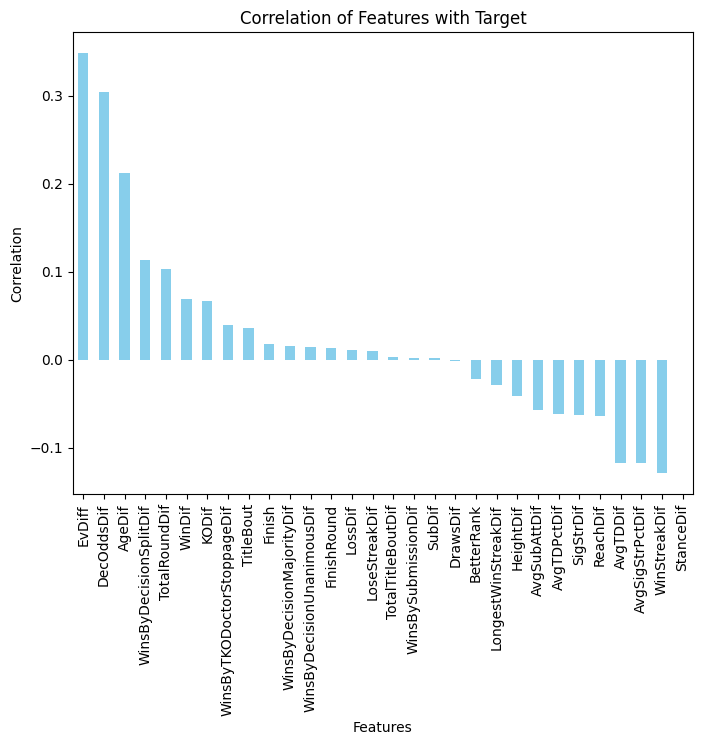

In [19]:
correlation_matrix2 = cleaned_data.corr()
target_correlation2 = correlation_matrix2['Winner'].sort_values(ascending=False)


print("Correlation of features with target:")
print(target_correlation2)

plt.figure(figsize=(8, 6))
target_correlation2.drop('Winner').plot(kind='bar', color='skyblue')
plt.title('Correlation of Features with Target')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()


In [20]:
target_correlation2.index[1:11]

Index(['EvDiff', 'DecOddsDif', 'AgeDif', 'WinsByDecisionSplitDif',
       'TotalRoundDif', 'WinDif', 'KODif', 'WinsByTKODoctorStoppageDif',
       'TitleBout', 'Finish'],
      dtype='object')

In [21]:
top_10 = target_correlation2.index[1:11]
print(f"Top 10 features correlated to winning: {list(top_10)}")

Top 10 features correlated to winning: ['EvDiff', 'DecOddsDif', 'AgeDif', 'WinsByDecisionSplitDif', 'TotalRoundDif', 'WinDif', 'KODif', 'WinsByTKODoctorStoppageDif', 'TitleBout', 'Finish']


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_ol

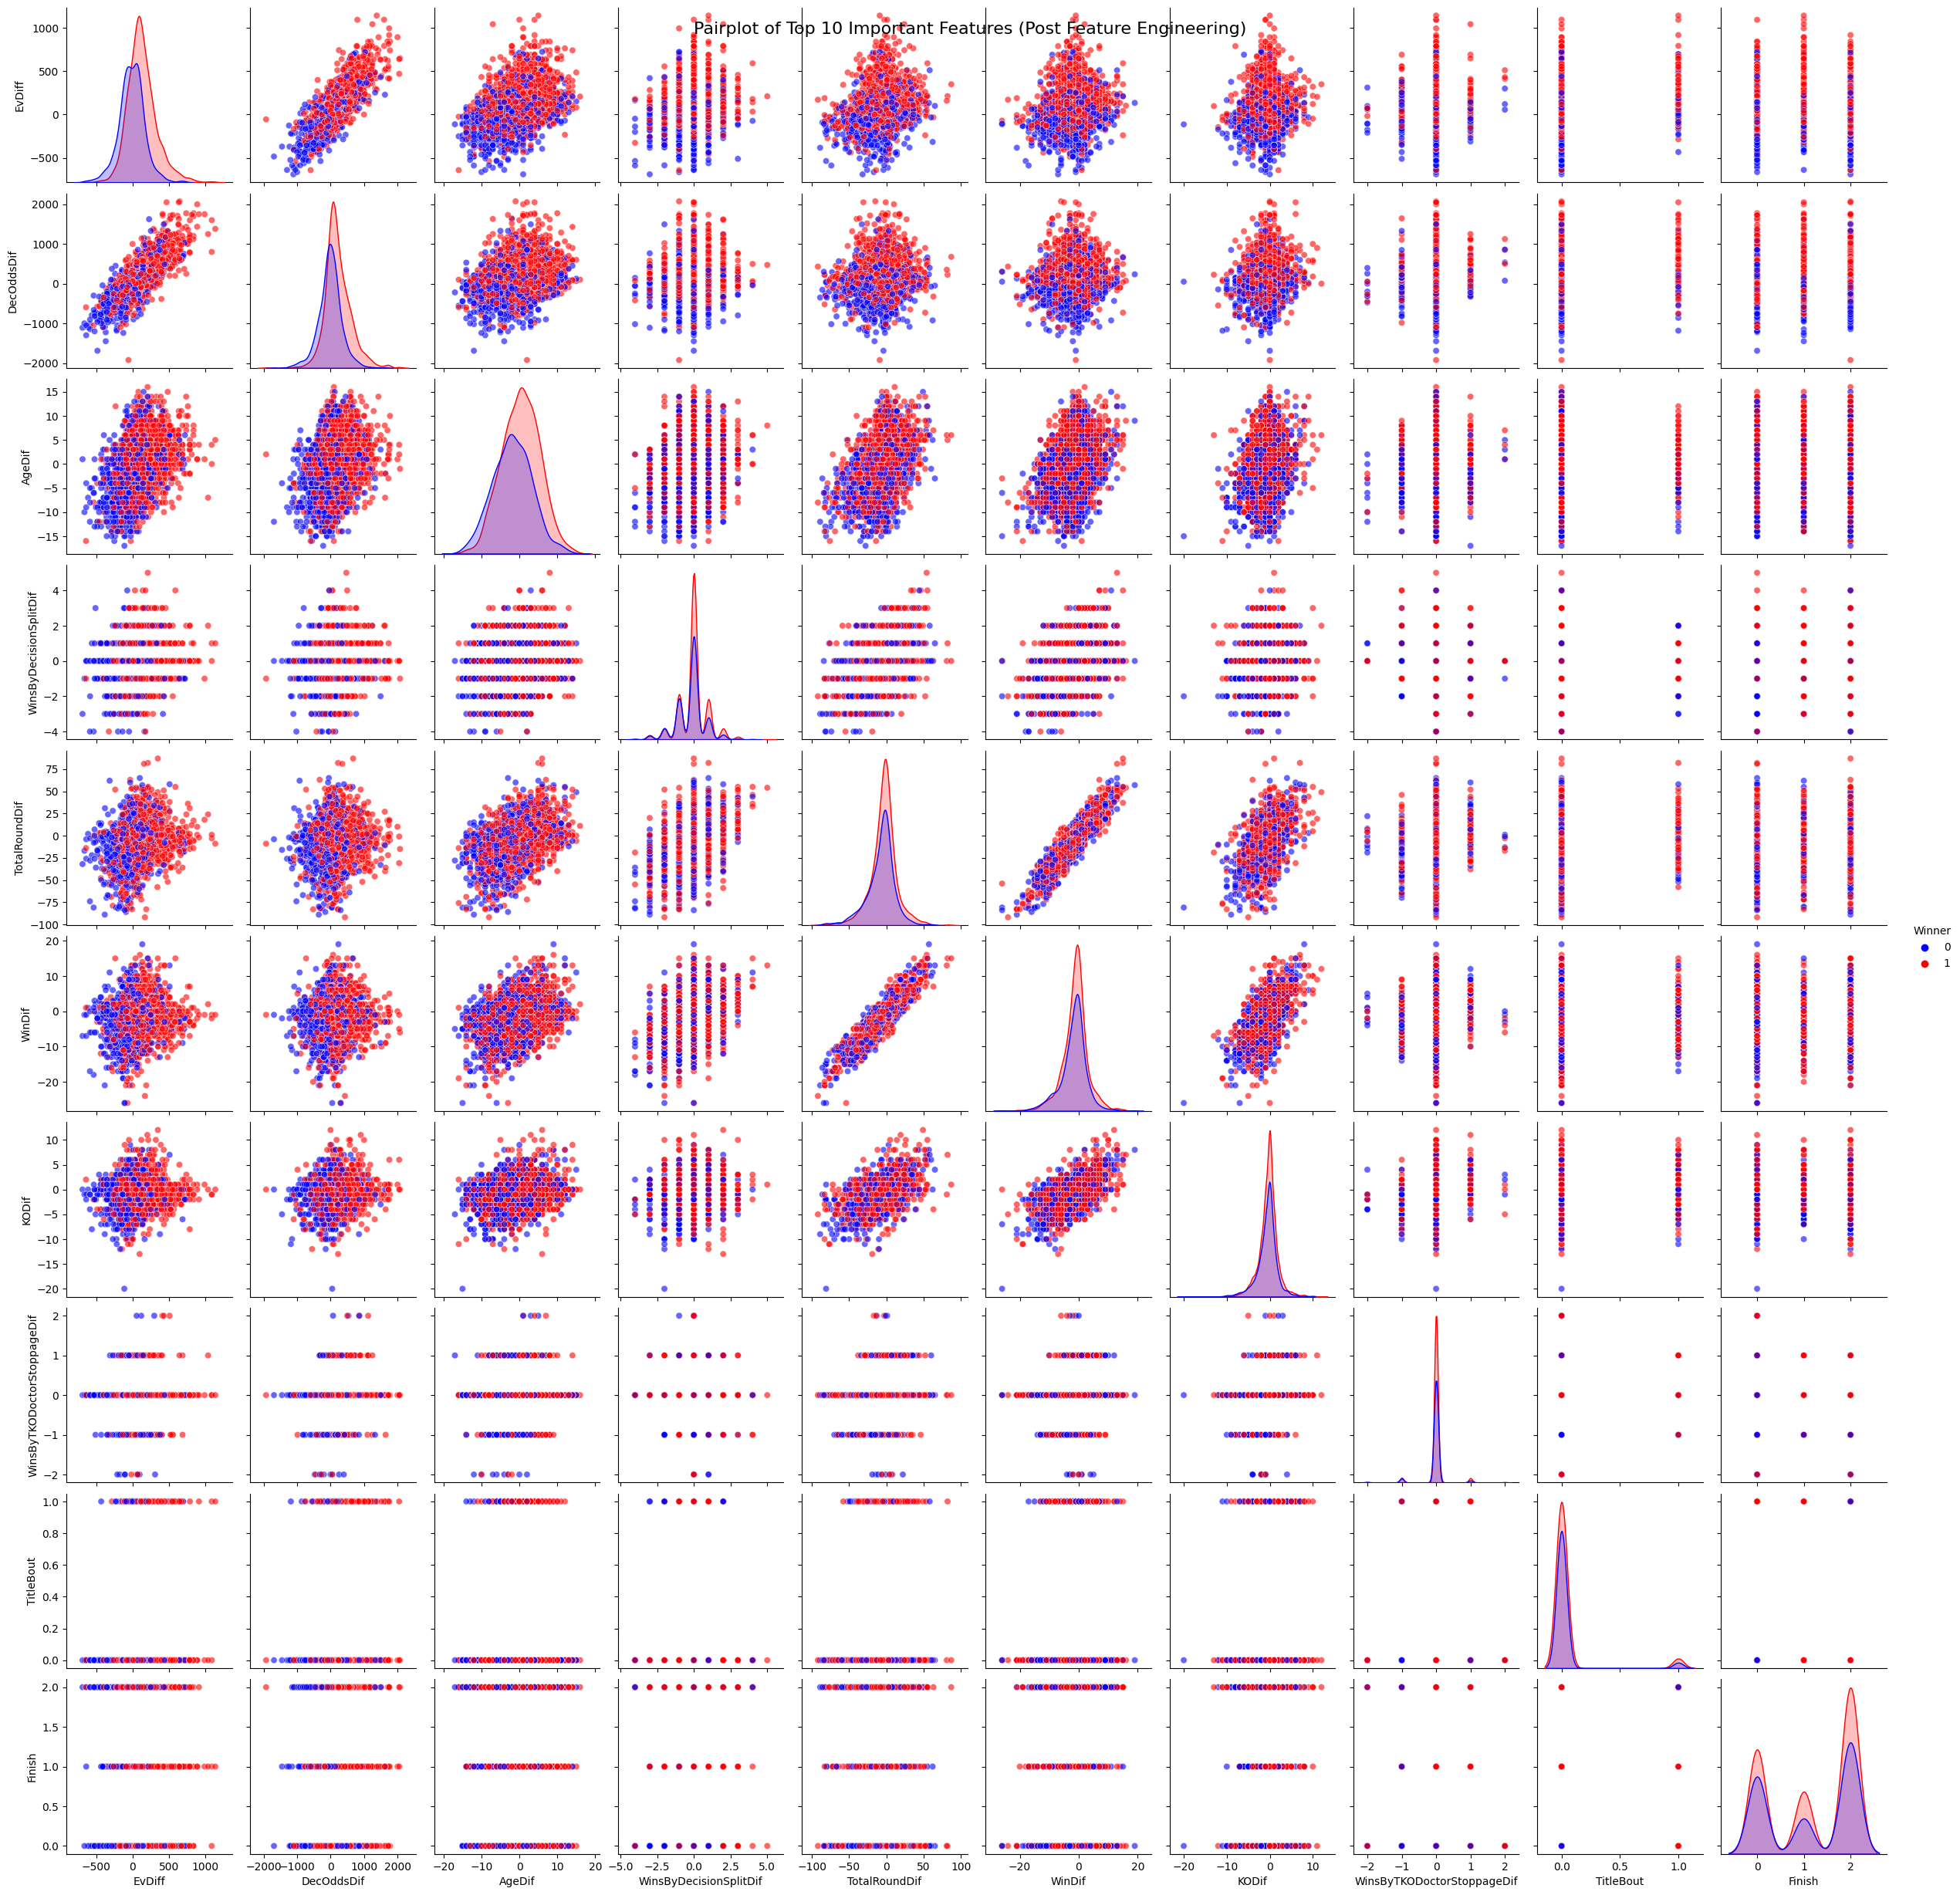

In [22]:
data_subset = cleaned_data[target_correlation2[:11].index]

sns.pairplot(data_subset, hue='Winner', palette={0: 'blue', 1: 'red'}, diag_kind='kde', plot_kws={'alpha': 0.6})

plt.suptitle("Pairplot of Top 10 Important Features (Post Feature Engineering)", size=16)
plt.show()

#### After feature engineering we can see new correlations and patterns exposed in our data, which are no longer directly related to the pre determined odds of a fight. It is interesting to see the high and low correlation between fighter attributes such as hight and reach difference, but high correlation with age difference. It can also be observed that linear relationships between total rounds fought (difference between blue and red) and win difference have emerged. Another interesting relationship is within age / experience related varibles, where more experienced fighters can be seen winning more when the fight means more (title bout).

## PCA

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()
data_clean_standardized= scaler.fit_transform(cleaned_data)

pca = PCA(n_components=5)
pca_result = pca.fit_transform(cleaned_data)


pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])


print("Explained variance by each component:", pca.explained_variance_ratio_)
pca_df.head()

Explained variance by each component: [9.38433086e-01 5.73581465e-02 1.78812403e-03 1.49232094e-03
 5.04091765e-04]


,PC1,PC2,PC3,PC4,PC5
0,-631.214384,-379.558388,-57.745951,10.937379,-12.371553
1,-679.862904,-4.345694,-35.935985,2.398386,3.476508
2,-453.086474,-48.208491,8.413382,-5.658409,-6.660795
3,-593.448653,-173.899352,39.852120,-9.931439,4.636106
4,-17.987284,36.236436,-34.809241,4.308853,-7.374968


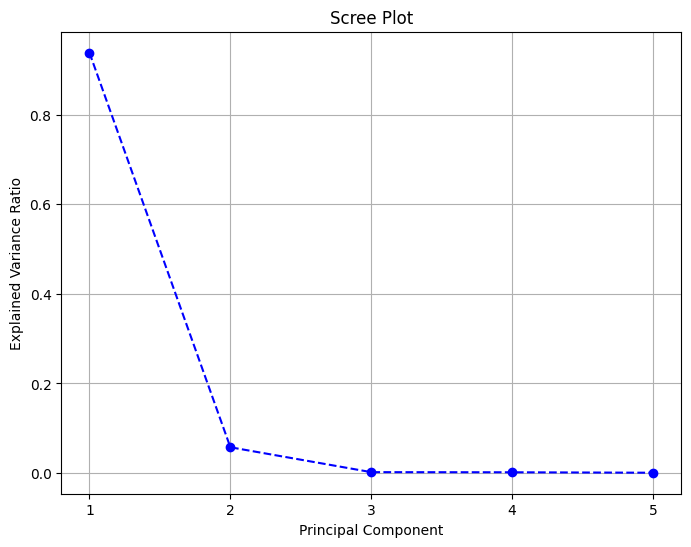

In [25]:
explained_variance_ratio = pca.explained_variance_ratio_
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', color='b')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(np.arange(1, len(explained_variance_ratio) + 1, 1))
plt.grid(True)
plt.show()

#### This scree plot shows that pc 1 and 2 explain the varience in almost the entire data set. 

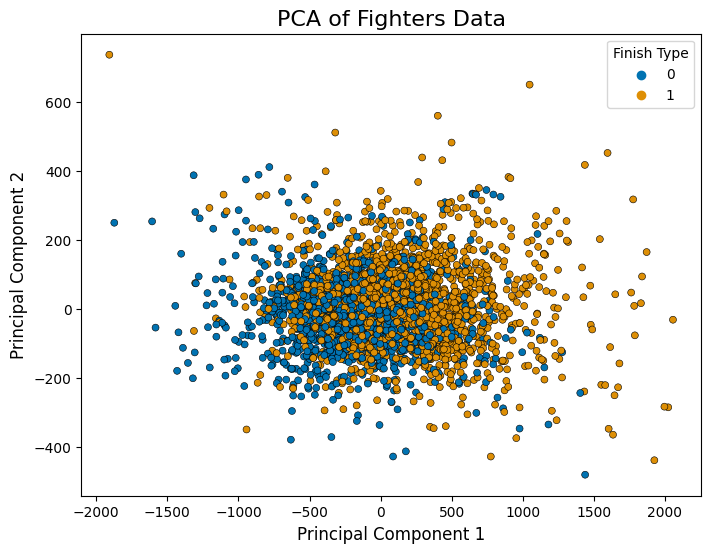

Explained variance by PC1: 0.938
Explained variance by PC2: 0.057


In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", data=pca_df, hue = cleaned_data['Winner'], s=25, edgecolor='black')
plt.title('PCA of Fighters Data', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Finish Type', loc='upper right')
plt.show()

explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by PC1: {explained_variance[0]:.3f}')
print(f'Explained variance by PC2: {explained_variance[1]:.3f}')

## PCA Takeaway
#### PCA has shown most of the varience explained in pc1 and 2 and a high quality sepperation between predictions when plotted. 93% of variance shown in one pc could potentally expose features relating to overfitting or a small amount of features that effect the whole data set. 
#### Using pc1 and 2 as features for my predictive modeling

# Predictive Modeling
## Logistic Regression on top 10 features and pcs

In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier


def compute_CV_error(model, X_train, Y_train):
    '''
    Split the training data into 4 subsets.
    For each subset, 
        fit a model holding out that subset
        compute the MSE on that subset (the validation set)
    You should be fitting 4 models total.
    Return the average MSE of these 4 folds.

    Args:
        model: an sklearn model with fit and predict functions 
        X_train (data_frame): Training data
        Y_train (data_frame): Label 

    Return:
        the average validation MSE for the 4 splits.
    '''
    kf = KFold(n_splits=4)
    validation_errors = np.empty(0)
    X_train = pd.DataFrame(X_train)
    Y_train = pd.DataFrame(Y_train)

    for train_idx, valid_idx in kf.split(X_train):
        
        # split the data
        split_X_train, split_X_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx]
      
        #  Fit the model on the training split
        model.fit(split_X_train, split_Y_train)
        
        # Predict housing prices on the test set
        split_Y_pred = model.predict(split_X_valid)

        # Compute the RMSE on the validation split

        valid_mse = mean_squared_error(split_Y_valid, split_Y_pred)
        valid_rmse = valid_mse ** 1/2
        validation_errors = np.append(validation_errors, valid_rmse)
              
    return np.mean(validation_errors)

Accuracy: 68.06%
Confusion Matrix:
[[180 176]
 [ 83 372]]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/uti

Linear Regression Model CV error: 16.91%


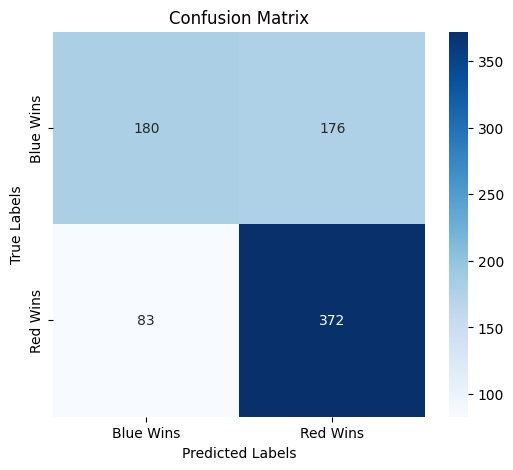

In [28]:
target = cleaned_data['Winner']
X = cleaned_data[top_10]
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

cv_error = compute_CV_error(log_reg, X_train, y_train) * 100
print(f"Linear Regression Model CV error: {cv_error:0.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Blue Wins', 'Red Wins'], yticklabels=['Blue Wins', 'Red Wins'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


### 68% accuracy on this model 

Accuracy: 66.71%
Confusion Matrix:
[[180 176]
 [ 83 372]]
Linear Regression Model CV error: 17.39%


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/uti

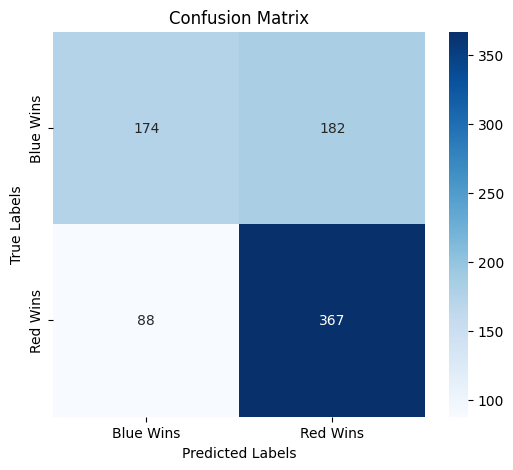

In [29]:
target = cleaned_data['Winner']
X = pca_df
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm2 = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{cm}")

cv_error = compute_CV_error(log_reg, X_train, y_train) * 100
print(f"Linear Regression Model CV error: {cv_error:0.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=['Blue Wins', 'Red Wins'], yticklabels=['Blue Wins', 'Red Wins'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


## Random Forest Classifier on top 10 fetures and pcs

Test Accuracy: 65.0246

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.53      0.56       171
           1       0.68      0.74      0.71       235

    accuracy                           0.65       406
   macro avg       0.64      0.63      0.63       406
weighted avg       0.65      0.65      0.65       406


Confusion Matrix:
[[ 90  81]
 [ 61 174]]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklea

RandomForestClassifier cv error: 17.36%


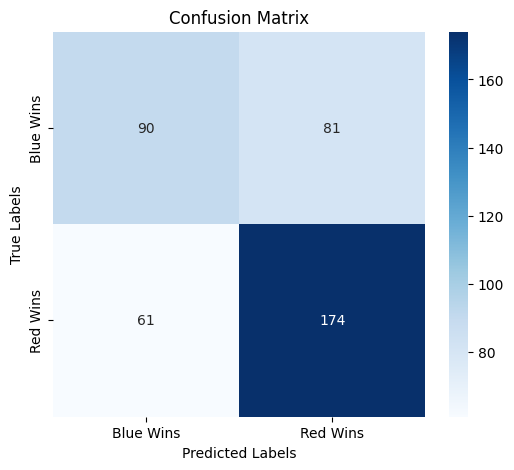

In [30]:
X2 = cleaned_data[top_10]
y2 = cleaned_data['Winner']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train2)
X_test_scaled = scaler.transform(X_test2)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train_scaled, y_train2)
y_pred2 = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test2, y_pred2) * 100
print(f"Test Accuracy: {accuracy:.4f}")

cm3 = confusion_matrix(y_test2, y_pred2)
print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

cv_error = compute_CV_error(rf_model, X_train2, y_train2) * 100
print(f"RandomForestClassifier cv error: {cv_error:0.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', xticklabels=['Blue Wins', 'Red Wins'], yticklabels=['Blue Wins', 'Red Wins'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


## Lower Accuracy using rfc model and top 10 features

Test Accuracy: 62.5616%

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.47      0.52       171
           1       0.66      0.74      0.69       235

    accuracy                           0.63       406
   macro avg       0.61      0.60      0.61       406
weighted avg       0.62      0.63      0.62       406


Confusion Matrix:
[[ 81  90]
 [ 62 173]]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklea

RandomForestClassifier cv error: 18.62%


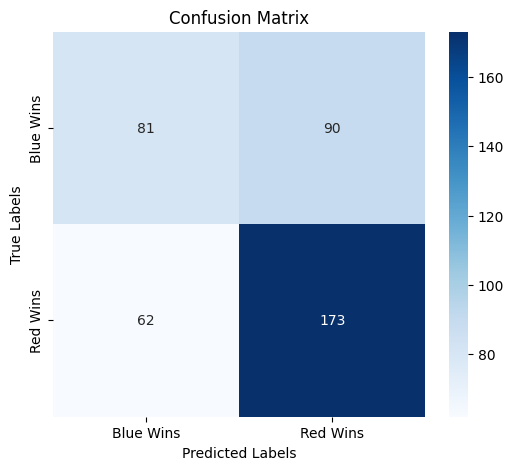

In [31]:
X3 = pca_df
y3 = cleaned_data['Winner']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size=0.1, random_state=42)


rf_model = RandomForestClassifier(n_estimators=300, random_state=42)


rf_model.fit(X_train3, y_train3)
y_pred3 = rf_model.predict(X_test3)

accuracy = accuracy_score(y_test3, y_pred3) * 100
print(f"Test Accuracy: {accuracy:.4f}%")

cm4 = confusion_matrix(y_test3, y_pred3)

print("\nClassification Report:")
print(classification_report(y_test3, y_pred3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test3, y_pred3))

cv_error = compute_CV_error(rf_model, X_train3, y_train3) * 100
print(f"RandomForestClassifier cv error: {cv_error:0.2f}%")

plt.figure(figsize=(6, 5))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues', xticklabels=['Blue Wins', 'Red Wins'], yticklabels=['Blue Wins', 'Red Wins'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


#### Better accuracy but higher cv error using pc 1 and 2 in the same model

## Predictive Analysis Wrap up

#### Out of the 4 models I trained and tested (Log regression on top 10 features and PCs, Random Forest Classifier with same feature sets) the first model (Log regression and top 10 features) proved to be the most acurate with the lowest cv error (68% acc and 16.9% err).

#### I assume that there is some overfitting going on in this model, specificly relating to the expected value feature. Because this expective value is a predictive feature the high cv error could be explained in my models. Also, looking at my PCA it can be seen that the data can be explained in a limited amount of features.. providing a reasoning for overfitting relating to EV. For future model training, I could optimize model parameters to reduce cv error, look at the relationship between ev and winning more closley as well as fine tune my feature set.

##### Overall, my biggest takeaway from this project is the amount of varibility that comes with sports data, expecally with the UFC a traditionally hard sport to predict and model. With a sport like mixed martial arts they say that anything can happen in the octagon, so I am pleased with the results of this project and excited to further explore the sport and related data science questions.